In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [15]:
data = pd.read_excel('Dry_Bean_Dataset.xlsx')
X = data.drop('Class', axis=1).values
y = data['Class'].values

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000, C=0.1)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.94      0.88      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.82      0.89      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [18]:
svm = SVC(C=1.0, class_weight='balanced', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print("SVM")
print(classification_report(y_test, y_pred_svm))

SVM
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.94      0.89      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.93      0.96      0.94       406
        SIRA       0.86      0.90      0.88       527

    accuracy                           0.92      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.92      0.92      2723



In [19]:
class BeanDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

classes = sorted(data['Class'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
y_train_idx = np.array([class_to_idx[c] for c in y_train])
y_test_idx = np.array([class_to_idx[c] for c in y_test])

train_dataset = BeanDataset(X_train_scaled, y_train_idx)
test_dataset = BeanDataset(X_test_scaled, y_test_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [34]:
class BeanClassifier(nn.Module):
    def __init__(self, input_size, num_classes, dropout_prob=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, num_classes)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

In [35]:
model = BeanClassifier(X_train_scaled.shape[1], len(classes))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 750
train_losses, test_losses = [], []

for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        out = model(batch_x)
        loss = loss_fn(out, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            out = model(batch_x)
            test_loss += loss_fn(out, batch_y).item()
    avg_test = test_loss / len(test_loader)
    test_losses.append(avg_test)

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train loss: {avg_train:.4f} | test loss: {avg_test:.4f}")

Epoch   1 | train loss: 1.1784 | test loss: 0.5325
Epoch  50 | train loss: 0.2207 | test loss: 0.2016
Epoch 100 | train loss: 0.2129 | test loss: 0.2030
Epoch 150 | train loss: 0.1990 | test loss: 0.1981
Epoch 200 | train loss: 0.1976 | test loss: 0.1970
Epoch 250 | train loss: 0.1928 | test loss: 0.1977
Epoch 300 | train loss: 0.1921 | test loss: 0.1949
Epoch 350 | train loss: 0.1898 | test loss: 0.1965
Epoch 400 | train loss: 0.1895 | test loss: 0.1986
Epoch 450 | train loss: 0.1880 | test loss: 0.1967
Epoch 500 | train loss: 0.1846 | test loss: 0.1963
Epoch 550 | train loss: 0.1846 | test loss: 0.1983
Epoch 600 | train loss: 0.1860 | test loss: 0.1931
Epoch 650 | train loss: 0.1843 | test loss: 0.1969
Epoch 700 | train loss: 0.1805 | test loss: 0.1915
Epoch 750 | train loss: 0.1806 | test loss: 0.1962


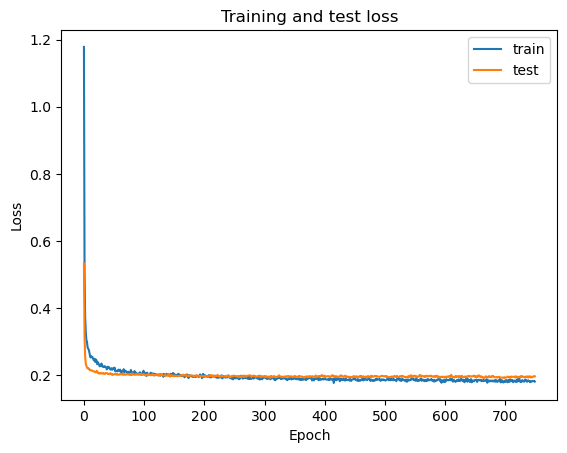

In [36]:
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and test loss')
plt.show()

In [37]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out = model(batch_x)
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

pred_names = [classes[i] for i in all_preds]
true_names = [classes[i] for i in all_true]
print("Neural Network")
print(classification_report(true_names, pred_names))

Neural Network
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.96      0.94      0.95       326
    DERMASON       0.89      0.95      0.92       709
       HOROZ       0.97      0.96      0.96       386
       SEKER       0.95      0.96      0.96       406
        SIRA       0.89      0.84      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723

